# Step 28 — cross-platform: the interferon score in each study

**Data types: RNA_array, bulk_RNA_seq, scRNA_seq pseudobulk.** **Reads:** `step10_site_*`,
`step23_GSE232381.rds`, `step25_GSE135779.rds`. **Writes:** `step28_ifn.rds`,
`figures/fig28_cross_platform_ifn.png`.

The score is scale-free: each gene is standardised against a reference **within its own study**, and
the score is the median across the six genes. So it can be compared across platforms, within limits:

- **GSE65391**: reference = healthy children (step 10);
- **GSE135779**: reference = its 11 healthy children;
- **GSE232381**: no healthy controls, so the reference is **all 16 patients**. Its scores are
  relative (0 = the average patient in this study), not "above healthy". Only the comparison of active
  with inactive nephritis inside the study is meaningful.

Each study sends a histogram of its scores per group.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
start_log("28")
ifn6 <- read_gene_set("ifn-type1-6.txt")
BREAKS <- seq(-6, 12, by = 0.5)
hist_of <- function(x) hist(pmin(pmax(x, -6), 12), BREAKS, plot = FALSE)$counts
H <- list()
for (s in SITES) { m <- readRDS(site_file("10", s))$meta
  H[[s]] <- send(list(healthy = hist_of(m$ifn_score[m$disease == "Healthy"]), SLE = hist_of(m$ifn_score[m$disease == "SLE"])),
                 s, "ifn histograms", nrow(m)) }
H65 <- list(healthy = Reduce(`+`, lapply(H[SITES], `[[`, "healthy")), SLE = Reduce(`+`, lapply(H[SITES], `[[`, "SLE")))
p <- readRDS(art("step25_GSE135779.rds"))
sp <- ifn_score(p$E, ifn6, reference = p$meta$disease == "Healthy")
H135 <- send(list(healthy = hist_of(sp$ifn_score[p$meta$disease == "Healthy"]), SLE = hist_of(sp$ifn_score[p$meta$disease == "SLE"])),
             "GSE135779", "ifn histograms", ncol(p$E))
b <- readRDS(art("step23_GSE232381.rds"))
sb <- ifn_score(b$E, ifn6, reference = rep(FALSE, ncol(b$E)))
unique(sb$basis)
H232 <- send(list(inactive = hist_of(sb$ifn_score[b$meta$ln_activity == "inactive"]), active = hist_of(sb$ifn_score[b$meta$ln_activity == "active"])),
             "GSE232381", "ifn histograms", ncol(b$E))

[1] "all samples"

## Within-study comparisons

In [2]:
mids <- head(BREAKS, -1) + 0.25
hmed <- function(h) mids[which(cumsum(h) >= sum(h) / 2)[1]]
data.frame(study = c("GSE65391", "GSE65391", "GSE135779", "GSE135779", "GSE232381", "GSE232381"),
           group = c("healthy", "SLE", "healthy", "SLE", "inactive LN", "active LN"),
           n = c(sum(H65$healthy), sum(H65$SLE), sum(H135$healthy), sum(H135$SLE), sum(H232$inactive), sum(H232$active)),
           approximate_median = c(hmed(H65$healthy), hmed(H65$SLE), hmed(H135$healthy), hmed(H135$SLE), hmed(H232$inactive), hmed(H232$active)))

study,group,n,approximate_median
<chr>,<chr>,<int>,<dbl>
GSE65391,healthy,48,-0.25
GSE65391,SLE,924,2.75
GSE135779,healthy,11,0.25
GSE135779,SLE,33,5.25
GSE232381,inactive LN,6,0.25
GSE232381,active LN,10,0.25


In [3]:
# inside each RNA sequencing study the samples are local, so exact tests are possible there
wilcox.test(sp$ifn_score[p$meta$disease == "SLE"], sp$ifn_score[p$meta$disease == "Healthy"])$p.value
wilcox.test(sb$ifn_score[b$meta$ln_activity == "active"], sb$ifn_score[b$meta$ln_activity == "inactive"])$p.value

[1] 2.111629e-05

[1] 0.4922577

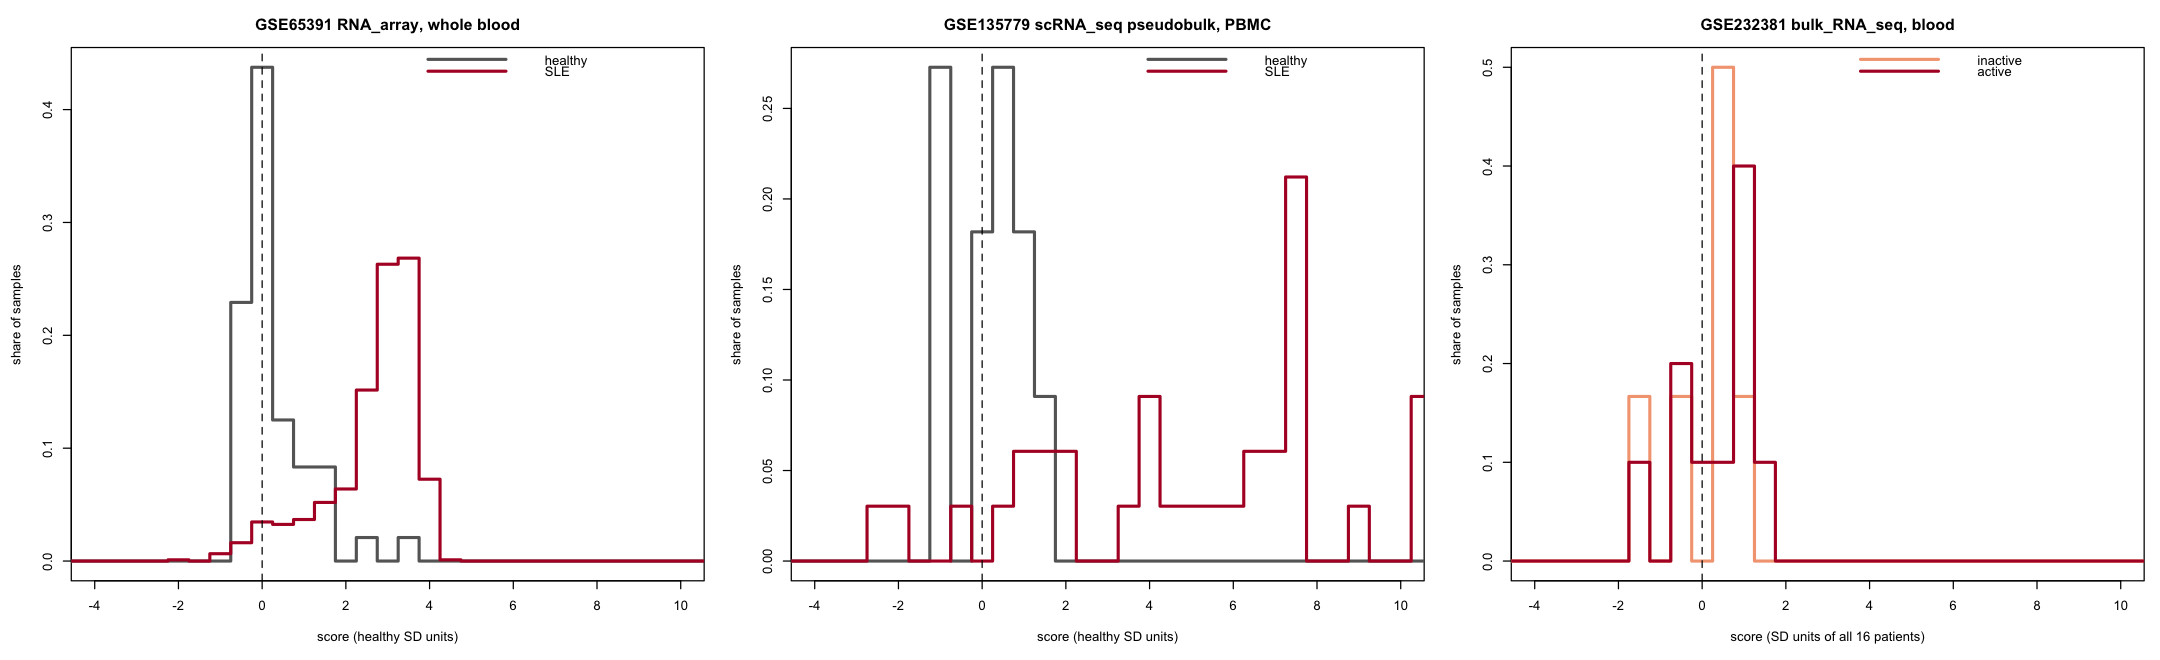

In [4]:
draw_ifn <- function() {
  op <- par(mfrow = c(1, 3), mar = c(5, 4.5, 3, 1))
  panel <- function(h, cols, main, xlab) {
    plot(NULL, xlim = c(-4, 10), ylim = c(0, max(sapply(h, function(x) max(x / sum(x))))),
         xlab = xlab, ylab = "share of samples", main = main)
    for (i in seq_along(h)) lines(mids, h[[i]] / sum(h[[i]]), col = cols[i], lwd = 2.5, type = "s")
    abline(v = 0, lty = 2); legend("topright", names(h), col = cols, lwd = 2.5, bty = "n")
  }
  panel(H65, c("grey40", "#B2182B"), "GSE65391 RNA_array, whole blood", "score (healthy SD units)")
  panel(H135, c("grey40", "#B2182B"), "GSE135779 scRNA_seq pseudobulk, PBMC", "score (healthy SD units)")
  panel(H232, c("#F4A582", "#B2182B"), "GSE232381 bulk_RNA_seq, blood", "score (SD units of all 16 patients)")
  par(op)
}
png(fig("fig28_cross_platform_ifn.png"), width = 2400, height = 750, res = 150); draw_ifn(); invisible(dev.off())
options(repr.plot.width = 18, repr.plot.height = 5.5); draw_ifn()

In [5]:
saveRDS(list(GSE135779 = sp, GSE232381 = sb), art("step28_ifn.rds"))

## Findings

- **GSE135779**: children with SLE score far above healthy children (approximate medians 5.3 against
  0.3 healthy SD units; Wilcoxon p = 2e-5). The gap is larger than in GSE65391 (2.8 against −0.3). With
  only 11 healthy references, and PBMC in place of whole blood, the SD units are not the same size, so
  the two studies agree in direction, not in magnitude.
- **GSE232381**: active and inactive nephritis do not differ (p = 0.49). With no healthy controls the
  score is relative to the average patient, so this says only that interferon does not track
  nephritis activity here. That matches GSE65391, where interferon barely rises with SLEDAI (step 10).